# Stage 2: Wafer Defect Map Exploratory Data Analysis (EDA)

This notebook contains the exploratory data analysis for the WM-811K wafer defect map dataset.
We will load the dataset, separate labeled/unlabeled samples, and plot the class distribution and sample wafer maps.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# If running inside notebooks directory, change directory to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Premium design plotting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#ffffff'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'
plt.rcParams['axes.edgecolor'] = '#dee2e6'
print('Imports and plotting configurations complete. Current working directory:', os.getcwd())

Imports and plotting configurations complete. Current working directory: C:\Users\userPC\Desktop\Workspace\01_Projects\WM811K_Portfolio


In [2]:
# Load the dataset
data_path = 'data/LSWMD.pkl'
print(f'Loading data from {data_path} (this might take a minute)...')
df = pd.read_pickle(data_path)
print(f'Dataset shape: {df.shape}')
print(df.info())

Loading data from data/LSWMD.pkl (this might take a minute)...


Dataset shape: (811457, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB
None


In [3]:
# Process raw labels. failureType and trianTestLabel are wrapped in nested arrays.
def clean_failure_type(val):
    if isinstance(val, np.ndarray) and val.size > 0:
        label = str(val[0][0]).strip()
        if label.lower() == 'none':
            return 'Normal'
        return label
    return 'None'

df['clean_failureType'] = df['failureType'].apply(clean_failure_type)
print('Unique values in clean_failureType:')
print(df['clean_failureType'].value_counts(dropna=False))

Unique values in clean_failureType:
clean_failureType
None         638507
Normal       147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [4]:
# Filter labeled and unlabeled datasets
labeled_df = df[df['clean_failureType'] != 'None'].copy()
unlabeled_df = df[df['clean_failureType'] == 'None'].copy()

print(f'Labeled Wafers Count: {len(labeled_df):,}')
print(f'Unlabeled Wafers Count: {len(unlabeled_df):,}')
assert len(labeled_df) == 172950, f'Expected 172,950 labeled wafers, got {len(labeled_df)}'
assert len(unlabeled_df) == 638507, f'Expected 638,507 unlabeled wafers, got {len(unlabeled_df)}'

Labeled Wafers Count: 172,950
Unlabeled Wafers Count: 638,507


In [5]:
# Labeled Class Distribution Table
dist = labeled_df['clean_failureType'].value_counts()
dist_df = pd.DataFrame({
    'Count': dist,
    'Percentage (%)': (dist / len(labeled_df) * 100).round(3)
})
print(dist_df)

                    Count  Percentage (%)
clean_failureType                        
Normal             147431          85.245
Edge-Ring            9680           5.597
Edge-Loc             5189           3.000
Center               4294           2.483
Loc                  3593           2.077
Scratch              1193           0.690
Random                866           0.501
Donut                 555           0.321
Near-full             149           0.086


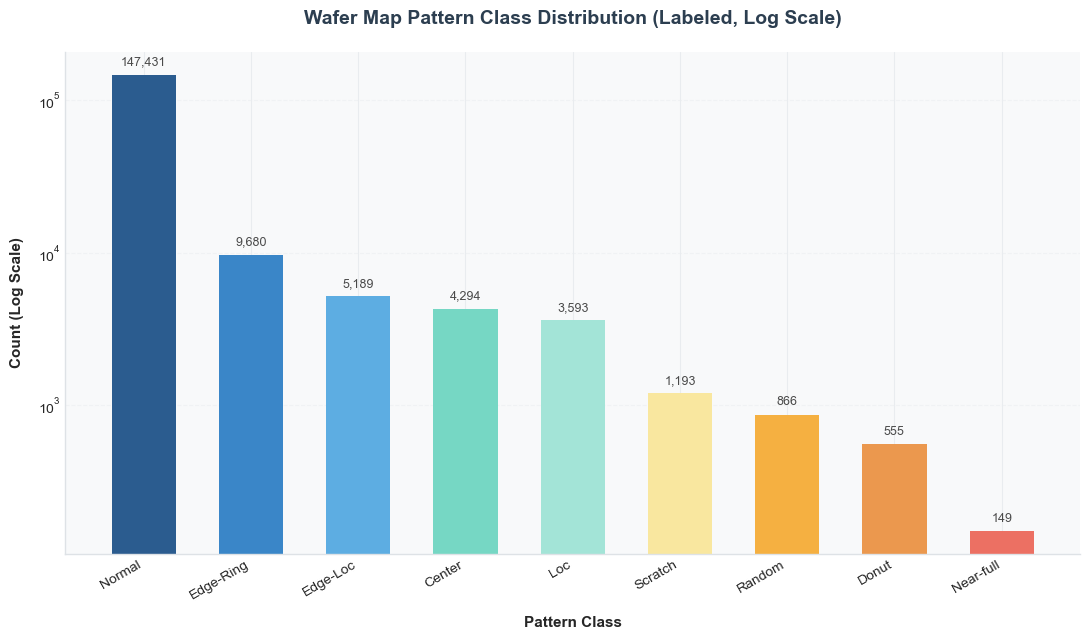

Saved class distribution chart to results/figures/class_distribution.png


In [6]:
# Plot Class Distribution and save to results/figures/class_distribution.png
os.makedirs('results/figures', exist_ok=True)

plt.figure(figsize=(11, 6.5))
# Premium sleek colors for visual impact
colors = ['#2b5c8f', '#3a86c8', '#5dade2', '#76d7c4', '#a3e4d7', '#f9e79f', '#f5b041', '#eb984e', '#ec7063']
if len(dist) > len(colors):
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(dist)))
else:
    colors = colors[:len(dist)]

bars = plt.bar(dist.index, dist.values, color=colors, width=0.6, edgecolor='none')
plt.yscale('log') # Log scale is necessary due to Normal class dominating

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval * 1.1, f'{yval:,}', ha='center', va='bottom', fontsize=9, color='#4A4A4A')

plt.title('Wafer Map Pattern Class Distribution (Labeled, Log Scale)', fontsize=14, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('Pattern Class', fontsize=11, labelpad=10, fontweight='bold')
plt.ylabel('Count (Log Scale)', fontsize=11, labelpad=10, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved class distribution chart to results/figures/class_distribution.png')

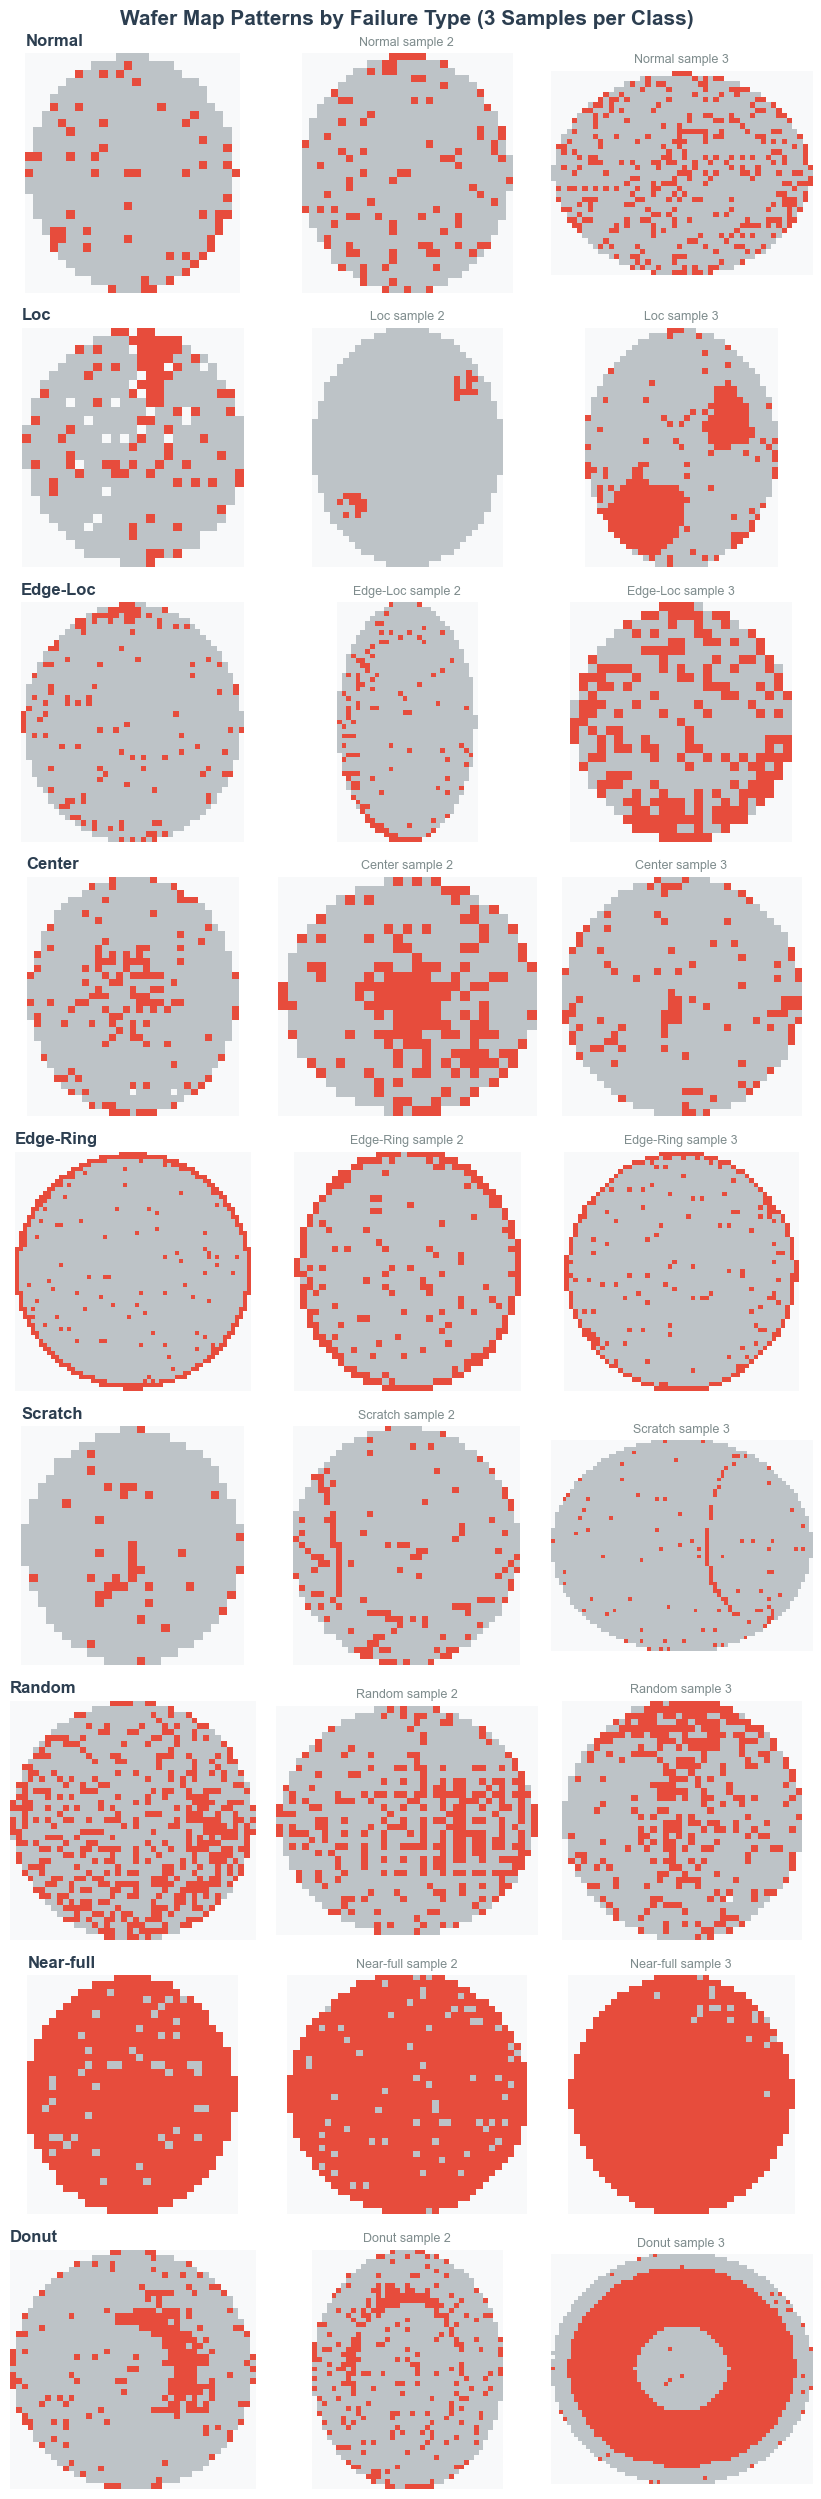

Saved sample wafer maps to results/figures/sample_wafers.png


In [7]:
# Plot sample wafer maps for each class (3 samples per class) and save to results/figures/sample_wafers.png
classes = labeled_df['clean_failureType'].unique()
n_classes = len(classes)
n_samples = 3

fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples * 2.8, n_classes * 2.8))

# Distinct custom discrete colormap for wafer visualization
# 0: Background/outside wafer -> Light Gray (#f8f9fa)
# 1: Normal die -> Slate Blue Gray (#bdc3c7)
# 2: Defect die -> Crimson Red (#e74c3c)
custom_cmap = ListedColormap(['#f8f9fa', '#bdc3c7', '#e74c3c'])

for idx, cls in enumerate(classes):
    # Select 3 random samples from current class
    cls_samples = labeled_df[labeled_df['clean_failureType'] == cls].sample(n=n_samples, random_state=42)
    for s_idx in range(n_samples):
        ax = axes[idx, s_idx]
        wafer_map = cls_samples.iloc[s_idx]['waferMap']
        ax.imshow(wafer_map, cmap=custom_cmap, interpolation='nearest')
        ax.axis('off')
        if s_idx == 0:
            ax.set_title(f'{cls}', fontsize=12, fontweight='bold', loc='left', color='#2c3e50')
        else:
            ax.set_title(f'{cls} sample {s_idx+1}', fontsize=9, color='#7f8c8d')

plt.suptitle('Wafer Map Patterns by Failure Type (3 Samples per Class)', fontsize=15, fontweight='bold', y=0.99, color='#2c3e50')
plt.tight_layout()
plt.savefig('results/figures/sample_wafers.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved sample wafer maps to results/figures/sample_wafers.png')

# Section 2: t-SNE Dimensionality Reduction and Visualization

We will subsample 500 wafer maps per class, resize them to a standard 28x28 grid, flatten them to 1D vectors, and apply t-SNE to visualize cluster separation between different failure types.

In [8]:
from sklearn.manifold import TSNE
from PIL import Image

# 1. Resize and Flatten function
def preprocess_for_tsne(wafer_map, target_size=(28, 28)):
    # Convert to PIL Image and resize using NEAREST neighbor to preserve discrete values (0, 1, 2)
    img = Image.fromarray(wafer_map.astype(np.uint8))
    img_resized = img.resize(target_size, resample=Image.NEAREST)
    return np.array(img_resized).flatten()

# 2. Subsample up to 500 samples per class to speed up t-SNE and prevent crowding
sampled_df = labeled_df.groupby('clean_failureType').apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
).reset_index(drop=True)

print('Sample counts per class for t-SNE:')
print(sampled_df['clean_failureType'].value_counts())

# Apply preprocessing
X = np.stack(sampled_df['waferMap'].apply(preprocess_for_tsne).values)
y = sampled_df['clean_failureType'].values
print(f'Feature matrix shape: {X.shape}, Labels shape: {y.shape}')

Sample counts per class for t-SNE:
clean_failureType
Center       500
Donut        500
Edge-Loc     500
Edge-Ring    500
Loc          500
Normal       500
Random       500
Scratch      500
Near-full    149
Name: count, dtype: int64
Feature matrix shape: (4149, 784), Labels shape: (4149,)


C:\Users\userPC\AppData\Local\Temp\ipykernel_17264\492483756.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = labeled_df.groupby('clean_failureType').apply(


In [9]:
# 3. Run t-SNE
print('Running t-SNE (perplexity=30)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X)
print('t-SNE completed.')

Running t-SNE (perplexity=30)...


t-SNE completed.


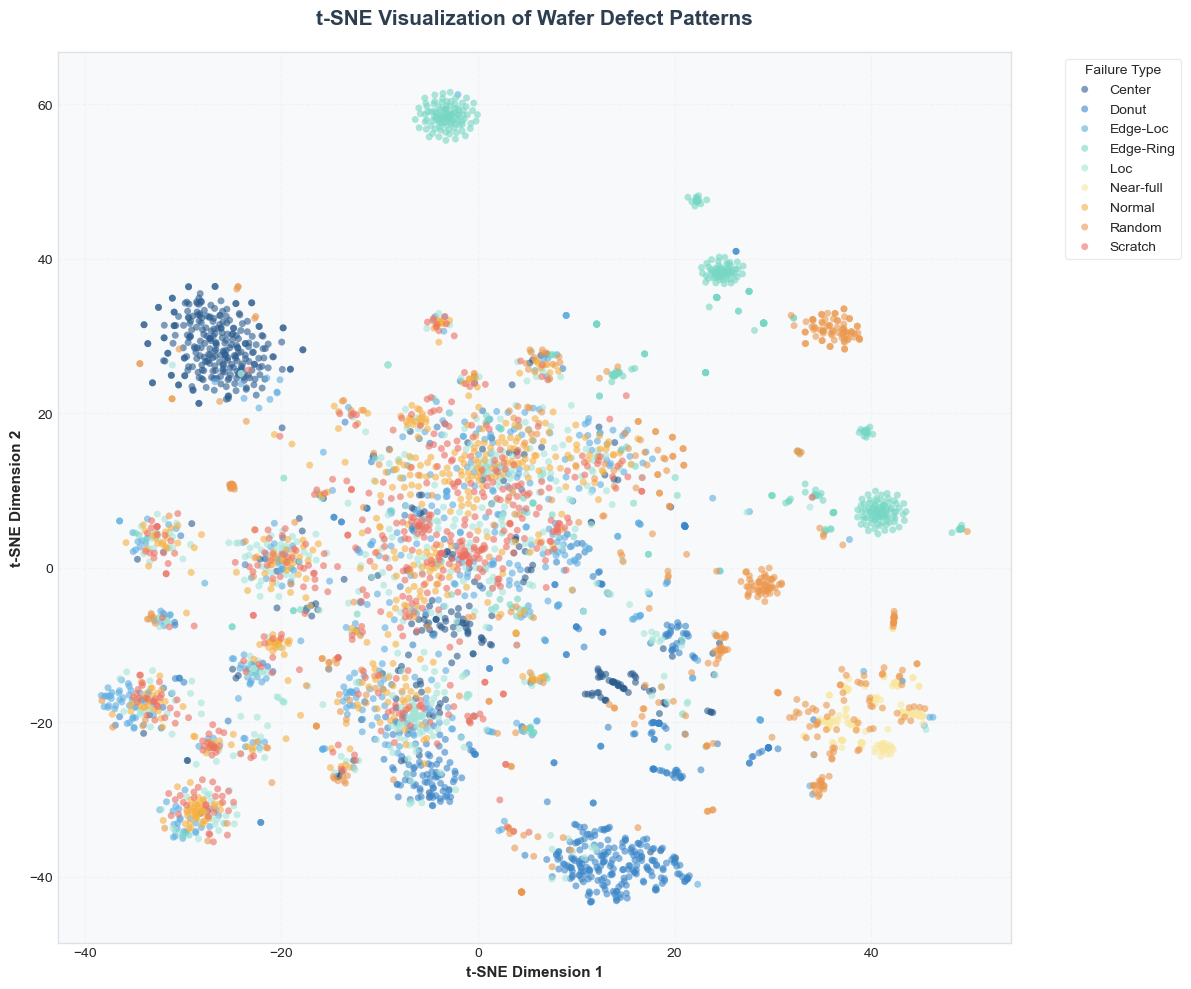

Saved t-SNE plot to results/figures/tsne_raw.png


In [10]:
# 4. Plot t-SNE results
plt.figure(figsize=(12, 10))

unique_classes = np.unique(y)
# Let's map classes to distinct colors
colors = ['#2b5c8f', '#3a86c8', '#5dade2', '#76d7c4', '#a3e4d7', '#f9e79f', '#f5b041', '#eb984e', '#ec7063']
color_map = {cls: colors[idx] for idx, cls in enumerate(unique_classes)}

for cls in unique_classes:
    idx = (y == cls)
    plt.scatter(
        X_tsne[idx, 0], 
        X_tsne[idx, 1], 
        label=cls, 
        color=color_map[cls],
        alpha=0.6, 
        edgecolors='none', 
        s=25
    )

plt.title('t-SNE Visualization of Wafer Defect Patterns', fontsize=15, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('t-SNE Dimension 1', fontsize=11, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=11, fontweight='bold')
plt.legend(title='Failure Type', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('results/figures/tsne_raw.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved t-SNE plot to results/figures/tsne_raw.png')